# Run this first !
Ensures correct libraries and imports data

In [2]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data as of 2026-09-30
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


In [3]:
# Start timer
import time
start_time = time.time()

# Import UBS data

In [4]:
# Import data
import pandas as pd

data = pd.read_csv('/Users/rdrobinson/Cambridge/boe-financial-analysis/notebooks/rachel/All_in_one/BERTopic_Test/sentiment_classification_output_UBS.csv')

In [5]:
data.head(5)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral,RBT_main_sentiment,RBT_main_sentiment_score,RBT_negative,RBT_neutral,RBT_positive
0,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33595,...,Neutral,0.633788,0.363612,2.599858e-03,6.337882e-01,RBT_neutral,0.585431,0.059447,0.585431,0.355122
1,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33597,...,Neutral,0.762569,0.000298,2.371330e-01,7.625688e-01,RBT_neutral,0.798390,0.040205,0.798390,0.161405
2,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33598,...,Neutral,0.995665,0.001492,2.842489e-03,9.956655e-01,RBT_neutral,0.609302,0.021320,0.609302,0.369378
3,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33599,...,Positive,1.000000,1.000000,1.214168e-07,7.975387e-08,RBT_positive,0.747497,0.004000,0.248504,0.747497
4,UBS,2022-Q1,earnings,2022-04-26,1,prepared,management,Ralph Hamers,NaN,33600,...,Positive,0.999991,0.999991,3.106961e-06,6.054839e-06,RBT_positive,0.880521,0.003450,0.116029,0.880521


# Apply BERTopic to sentences classified as "Negative" by FinBERT

## Sentences where FinBERT = Negative

In [6]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = negative

negative_sentences = data[data['main_sentiment'] == 'negative'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
negative_sentences = negative_sentences.sort_values(by=['quarter', 'speaker_role'])

negative_sentences.head(4)

,quarter,speaker_name,speaker_role,sentence,cleaned_text,main_sentiment,main_sentiment_score
360,2022-Q1,Amit Goel,analyst,So what you're seeing there and whether the ma...,"['youre', 'seeing', 'whether', 'margin', 'stab...",negative,0.562937
393,2022-Q1,Adam Terelak,analyst,I think that's the level when in previous cycl...,"['think', 'thats', 'level', 'previous', 'cycle...",negative,0.913481
448,2022-Q1,Flora Bocahut,analyst,And how much of this do you think could be rev...,"['much', 'think', 'could', 'reversed', 'coming...",negative,0.732441
449,2022-Q1,Flora Bocahut,analyst,The second question is regarding the client be...,"['second', 'question', 'regarding', 'client', ...",negative,0.837717


In [7]:
negative_sentences.shape

(764, 7)

## BERTopic Analysis

In [8]:
# Build topics from negative sentences only. The CSV stores cleaned_text as a
# serialized list, so use original sentences rather than joining its characters.
from bertopic import BERTopic
from umap import UMAP

negative_sentences_list = (
    data.loc[data["main_sentiment"].eq("negative"), "sentence"]
    .dropna()
    .astype(str)
    .tolist()
)

topic_model = BERTopic(
    umap_model=UMAP(random_state=42, n_jobs=1),
    calculate_probabilities=False,
)
topics, probs = topic_model.fit_transform(negative_sentences_list)
topic_model.get_topic_info()

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7469.76it/s]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,268,-1_the_in_and_to,"[the, in, and, to, of, that, you, on, we, so]",[So that's what I mean by the impact from depo...
1,0,68,0_expenses_operating_compensation_and,"[expenses, operating, compensation, and, perso...",[Operating expenses were down 4% on lower pers...
2,1,63,1_revenues_lower_by_fees,"[revenues, lower, by, fees, decreased, in, pro...","[Total revenue decreased 31%, with lower net m..."
3,2,54,2_of_the_cost_we,"[of, the, cost, we, to, gross, saves, and, cos...",[Of the around 13 billion in gross cost saves ...
4,3,49,3_ncl_billion_of_rwa,"[ncl, billion, of, rwa, the, around, to, in, i...","[For the remainder of the year, we expect NCL ..."
5,4,42,4_nii_in_expect_the,"[nii, in, expect, the, rate, to, percentage, b...","[For the first quarter, we expect a low single..."
6,5,38,5_capital_cet1_the_ratio,"[capital, cet1, the, ratio, our, of, to, paren...",[Our CET1 capital ratio at the end of December...
7,6,32,6_credit_suisse_the_suisses,"[credit, suisse, the, suisses, of, loss, and, ...",[Credit loss expense in the quarter was 154 mi...
8,7,23,7_geopolitical_macroeconomic_and_uncertainty,"[geopolitical, macroeconomic, and, uncertainty...","[However, continued elevated geopolitical and ..."
9,8,23,8_quarter_the_we_in,"[quarter, the, we, in, bit, seeing, fourth, so...",[And probably had the inverse dynamic happenin...


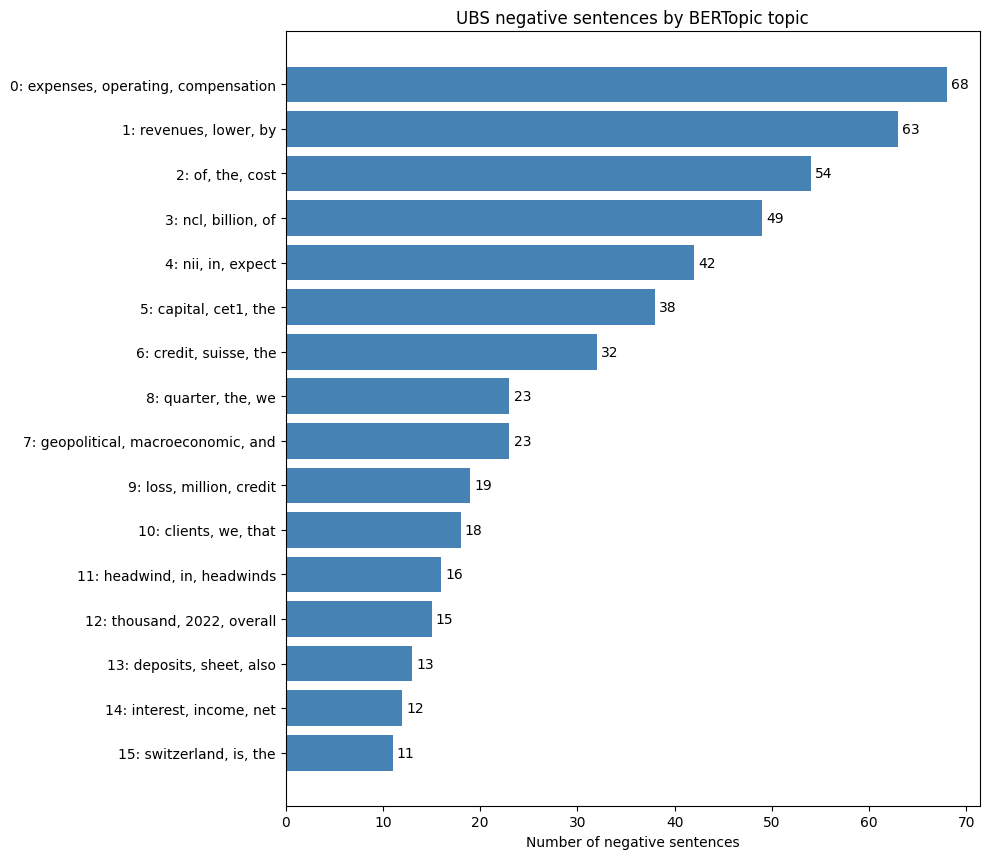

In [9]:
import matplotlib.pyplot as plt

topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1]  # drop the outlier "topic"
topic_info = topic_info.sort_values("Count")

# Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
labels = [
    f"{row.Topic}: " + ", ".join(row.Name.split("_")[1:4])
    for row in topic_info.itertuples()
]

fig, ax = plt.subplots(figsize=(10, 0.45 * len(topic_info) + 1.5))
bars = ax.barh(labels, topic_info["Count"], color="steelblue")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of negative sentences")
ax.set_title("UBS negative sentences by BERTopic topic")
plt.tight_layout()
plt.show()


There is also the issue of small words creeping in as these are the sentences rather than the cleaned text. 
Somehow the cleaned text needs to be amended to allow BERTopic to run

# Re-test with cleaned_text

In [12]:
# Filter data to only have FinBERT = negative
negative_data = data[data['main_sentiment'] == 'negative']

import ast
texts_for_bertopic_negative = [" ".join(ast.literal_eval(t)) for t in negative_data["cleaned_text"]]

In [ ]:
# Re-run BERTopic on the negative texts
cl_topic_model_negative = BERTopic()
cl_topics_negative, cl_probabilities_negative = cl_topic_model_negative.fit_transform(texts_for_bertopic_negative)
cl_topic_info_negative = cl_topic_model_negative.get_topic_info()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6764.69it/s]


: 

## Comparison to Jack's work
Jack seems to have plotted the top 3 topics by bank per quarter as a vertical graph.  

This would mean running BERTopic separately for each bank and each quarter, extracting the top 3 topics, and then plotting them in a vertical bar chart.